**Hipóteses revisadas:** H1 e H5 descrevem associações no recorte observado. H2 é não verificável: IDs reciclados impedem testar histórico escolar verdadeiro. Os resultados foram explorados na mesma população e não constituem confirmação independente.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src import config, eda
from src.evaluation import interpret as it
from src.modeling import campeao
from src.preprocessing import pipeline as pl
from src.visualization import plots_interpretabilidade as plots

eda.aplicar_estilo()
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

print("interpretador", sys.executable)
print("RANDOM_STATE ", config.RANDOM_STATE)

interpretador C:\Users\Vyctor\Documents\pos-tech\fase-3\Fase3_TechChallenge-Predicao-Inteligencia-Analitica-para-Alfabetizacao-no-Brasil\.venv\Scripts\python.exe
RANDOM_STATE  42


---
## 1. O que está sendo explicado, e sobre qual população

**Pergunta:** o artefato em disco é o mesmo que produziu o número publicado?
**Decisão:** seguir com a leitura ou parar e retreinar.

O `hash_dataset` gravado dentro do `joblib` é conferido contra o Parquet atual antes de qualquer conta. Explicar um modelo com um arquivo de dados diferente do que o treinou produz uma leitura plausível e falsa, e nenhuma métrica desta etapa denunciaria isso sozinha.

In [2]:
pacote = campeao.carregar_campeao()
resumo = json.loads(it.JSON_INTERPRET.read_text(encoding="utf-8"))

print("hash do dataset confere:", pacote["hash_dataset"] == campeao.hash_do_dataset())
print("features de entrada    :", len(pacote["features"]))
print("colunas pós-transform  :", len(pacote["nomes_apos_pre_processamento"]))
print("isotônica aplicada     :", pacote["modelo"].aplicar_)
print("versões                :", resumo["versoes"])
print()
print("amostra de SHAP        :", resumo["amostra_shap"])
print("permutação             :", resumo["permutacao"])

hash do dataset confere: True
features de entrada    : 20
colunas pós-transform  : 89
isotônica aplicada     : False
versões                : {'sklearn': '1.8.0', 'lightgbm': '4.7.0', 'shap': '0.52.0'}

amostra de SHAP        : {'n': 50000, 'n_gold': 43263, 'origem': 'conjunto de teste, municípios inéditos', 'valor_esperado_log_odds': -0.43595744974951317}
permutação             : {'n': 330836, 'n_repeticoes': 10, 'piso_de_ruido': 0.002, 'roc_auc_referencia': 0.6598992919366803}


**A amostra é de teste, não de treino.** São 50.000 alunos sorteados entre os 330.836 de municípios inéditos, dos quais 43.263 têm o lag vindo da Gold. Explicar o modelo no dado que ele memorizou devolveria a importância do que foi decorado; a permutação, que roda sobre o teste inteiro, tem a mesma exigência.

A isotônica está desligada — a Etapa 4 a rejeitou por não melhorar o Brier fora do próprio ajuste —, então o `TreeExplainer` ataca o `LGBMClassifier` diretamente e a explicação é exata, não aproximada por amostragem.

---
## 2. O mapa de 89 colunas para 20 features e 5 famílias

**Pergunta:** onde cada valor SHAP precisa ser creditado?
**Decisão:** a unidade em que a importância é reportada.

O `ColumnTransformer` transforma 20 features de entrada em 89 colunas: 14 valores numéricos, 12 indicadores de nulo e 63 dummies. `sigla_uf` sozinha vira 26 colunas. Sem devolver esse crédito à variável de origem, a leitura compara uma coluna contínua com um vigésimo sexto de uma variável categórica.

O mapa é construído a partir do transformador **ajustado**, e a reconstrução é conferida posição a posição contra `get_feature_names_out()`. Casamento de string sozinho colocaria as dummies de `fonte_lag_municipal` dentro de `fonte_lag_uf` em silêncio.

In [3]:
mapa = pd.read_csv(it.CSV_MAPA)
print(mapa.pivot_table(index="familia", columns="tipo", values="coluna", aggfunc="count", fill_value=0)
      .assign(colunas=lambda d: d.sum(axis=1))
      .join(mapa.groupby("familia")["feature"].nunique().rename("features"))
      .sort_values("colunas", ascending=False)
      .to_string())
print()
print("colunas por feature, as cinco maiores:")
print(mapa["feature"].value_counts().head(5).to_string())

                     dummy  indicador_de_nulo  valor  colunas  features
familia                                                                
territorial             31                  3      3       37         5
estrutural              32                  0      1       33         5
historico_municipal      0                  7      7       14         7
metas                    0                  2      2        4         2
historico_escolar        0                  0      1        1         1

colunas por feature, as cinco maiores:
feature
sigla_uf               26
caderno                22
nome_regiao             5
fonte_lag_municipal     4
rede_grupo              3


**Achado 1, a codificação distribui o peso de forma muito desigual entre as variáveis.** `sigla_uf` ocupa 26 das 89 colunas e `caderno` outras 22, enquanto `mun_media_portugues_lag1` ocupa duas. Num ranking coluna a coluna, a UF aparece fatiada em 26 pedaços pequenos e some do topo; a variável municipal aparece inteira. É um artefato de codificação, e é exatamente por isso que a leitura por família deixou de ser refinamento nesta etapa.

---
## 3. SHAP global — magnitude e direção

**Pergunta:** de quanto cada coluna move a predição, e para que lado?
**Decisão:** o conteúdo da resposta executiva sobre fatores.

O `beeswarm` é o gráfico principal porque carrega direção junto da magnitude. Barra ordenada por |SHAP| diz quem importa; o enxame diz se valor alto empurra a criança para o risco ou para longe dele.

C:\Users\Vyctor\Documents\pos-tech\fase-3\Fase3_TechChallenge-Predicao-Inteligencia-Analitica-para-Alfabetizacao-no-Brasil\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


images/interpretabilidade/01_shap_beeswarm.png


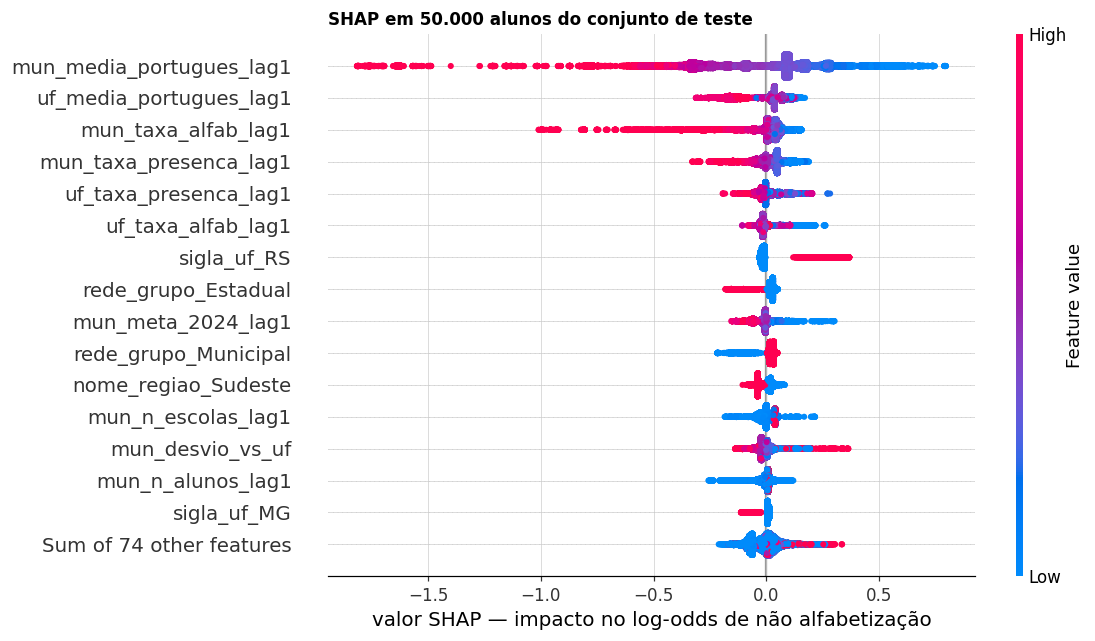

In [4]:
amostra = pd.read_parquet(it.PARQUET_SHAP)
fig = plots.plotar_beeswarm(amostra, pacote)
print(plots.salvar_figura(fig, "01_shap_beeswarm"))

                 feature             familia  n_colunas  media_do_abs_da_soma  participacao  cancelamento_interno
mun_media_portugues_lag1 historico_municipal          2                0.2709        0.3298                0.0000
 uf_media_portugues_lag1         territorial          2                0.0827        0.1007                0.0000
     mun_taxa_alfab_lag1 historico_municipal          2                0.0653        0.0795                0.0052
              rede_grupo          estrutural          3                0.0574        0.0699                0.0001
  mun_taxa_presenca_lag1 historico_municipal          2                0.0557        0.0678                0.0000
                sigla_uf         territorial         26                0.0494        0.0601                0.3946
             nome_regiao         territorial          5                0.0379        0.0461                0.1920
   uf_taxa_presenca_lag1         territorial          2                0.0330        0.0

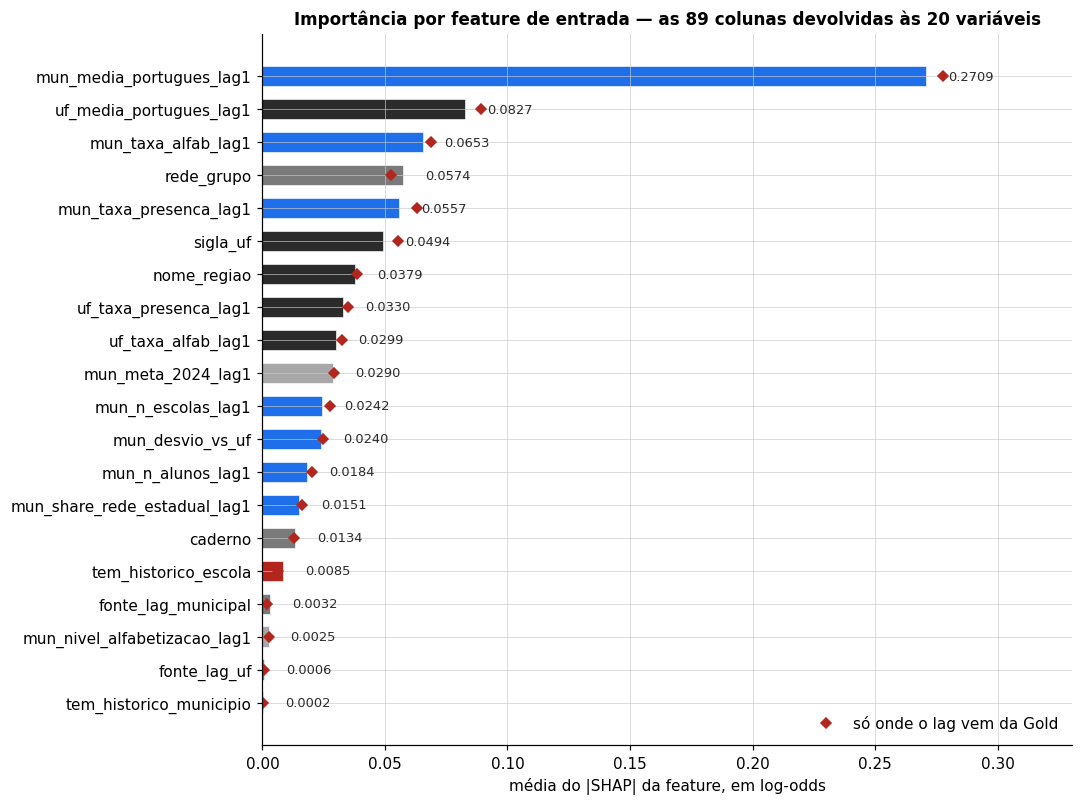

In [5]:
shap_features = pd.read_csv(it.CSV_SHAP_FEATURES)
global_ = shap_features[shap_features["recorte"] == "global"].copy()
global_["participacao"] = global_["media_do_abs_da_soma"] / global_["media_do_abs_da_soma"].sum()
print(global_[["feature", "familia", "n_colunas", "media_do_abs_da_soma", "participacao", "cancelamento_interno"]]
      .head(10).round(4).to_string(index=False))

fig = plots.plotar_barras_por_feature(shap_features)
print(plots.salvar_figura(fig, "02_shap_por_feature"))

**Achado 2, uma variável responde por quase um terço de tudo.** `mun_media_portugues_lag1` — a proficiência média em português do município em 2023 — tem |SHAP| médio de 0,271 em log-odds, **3,3 vezes** a segunda colocada e 33,0% de toda a movimentação do modelo. As três seguintes somadas não a alcançam.

**Achado 3, a direção é a esperada e é forte.** No enxame, valores altos de proficiência municipal (vermelho) ficam à esquerda, empurrando o log-odds de não alfabetização para baixo em até 1,8 — o que perto da prevalência de 0,38 vale dezenas de pontos percentuais de probabilidade. Nenhuma variável aparece com sinal invertido em relação ao que a EDA mediu, o que é a primeira conferência de sanidade da etapa.

**Achado 4, o `caderno` se comportou como controle negativo também aqui.** Ele ocupa 22 colunas e some do topo: somadas, elas ficam em 1,6% do total e na 15ª posição entre as 20 features. Se tivesse aparecido alto, o achado a reportar seria sobreajuste a ruído, e não uma leitura educacional sobre versões de prova.

---
## 4. Importância por família — a leitura que o plano tornou obrigatória

**Pergunta:** quanto vale cada bloco de variáveis, somado o crédito que a colinearidade repartiu?
**Decisão:** a resposta à pergunta 5 do enunciado, que é por grupo de variável.

Duas medidas, porque são duas perguntas. A participação no |SHAP| diz de quanto a família move a predição. A permutação em bloco — embaralhar todas as colunas da família de uma vez, com o mesmo vetor de posições — diz quanto ela vale **depois** de descontado o que as outras famílias já explicam.

            familia  n_features  n_colunas  participacao  cancelamento_interno  queda_permutacao_em_bloco  queda_permutacao_dp  acima_do_piso
historico_municipal           7         14       0.57163               0.24132                    0.08277              0.00090           True
        territorial           5         37       0.27593               0.36906                    0.04623              0.00056           True
         estrutural           5         33       0.09074               0.33874                    0.00329              0.00024           True
              metas           2          4       0.04821               0.04956                    0.00300              0.00015           True
  historico_escolar           1          1       0.01349               0.00000                    0.00010              0.00004          False
images/interpretabilidade/03_importancia_por_familia.png


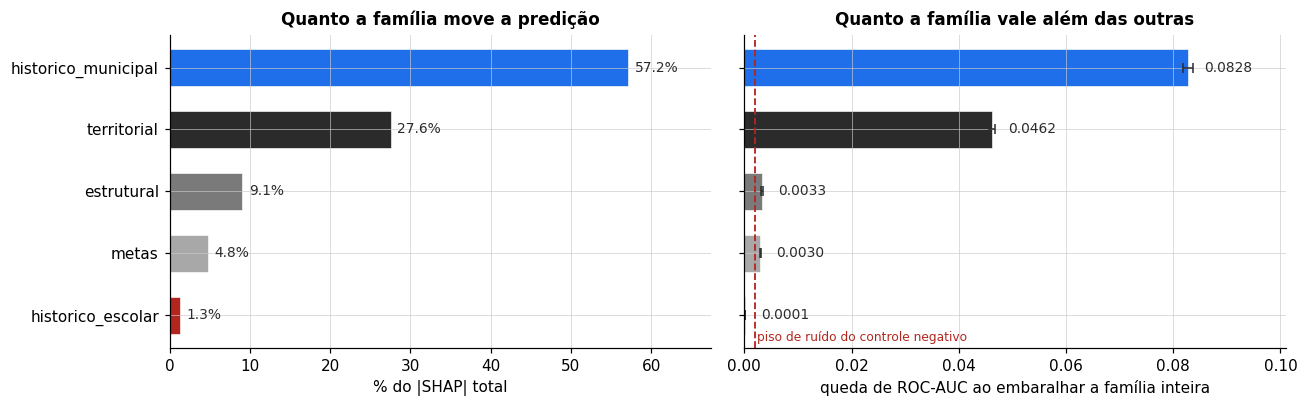

In [6]:
familias = pd.read_csv(it.CSV_FAMILIAS)
print(familias[familias["recorte"] == "global"]
      [["familia", "n_features", "n_colunas", "participacao", "cancelamento_interno",
        "queda_permutacao_em_bloco", "queda_permutacao_dp", "acima_do_piso"]]
      .round(5).to_string(index=False))

fig = plots.plotar_familias(familias)
print(plots.salvar_figura(fig, "03_importancia_por_familia"))

In [7]:
permutacao = pd.read_csv(it.CSV_PERMUTACAO)
blocos = pd.read_csv(it.CSV_PERMUTACAO_FAMILIA).set_index("bloco")

comparacao = pd.DataFrame({
    "soma_das_colunas_isoladas": permutacao.groupby("familia")["queda_media"].sum(),
    "familia_embaralhada_junta": blocos["queda_media"],
})
comparacao["quanto_a_leitura_isolada_perde"] = (
    comparacao["familia_embaralhada_junta"] / comparacao["soma_das_colunas_isoladas"]
)
print(comparacao.sort_values("familia_embaralhada_junta", ascending=False).round(5).to_string())

                     soma_das_colunas_isoladas  familia_embaralhada_junta  quanto_a_leitura_isolada_perde
historico_municipal                    0.05126                    0.08277                         1.61489
territorial                            0.02436                    0.04623                         1.89827
estrutural                             0.00338                    0.00329                         0.97436
metas                                  0.00305                    0.00300                         0.98372
historico_escolar                      0.00010                    0.00010                         1.04418


**Achado 5, o histórico municipal domina, e a hipótese H1 se sustenta.** A família responde por **57,2%** do |SHAP| e por uma queda de **0,0828** de ROC-AUC quando embaralhada inteira — quase o dobro da segunda colocada nas duas réguas. O critério de falseamento escrito na EDA era "uma família não municipal aparecer no topo do SHAP", e nenhuma apareceu.

**Achado 6, a leitura coluna a coluna subestima exatamente onde há redundância, e o efeito foi medido.** Somar as quedas das colunas isoladas da família municipal dá 0,0513; embaralhar a família junta dá 0,0828, **1,61 vez mais**. Na família territorial a razão é **1,90**. Já em metas, estrutural e histórico escolar a razão fica em 0,98 a 1,00 — famílias sem redundância interna não ganham nada com o agrupamento. É a demonstração numérica de que o agrupamento corrige um viés real, e não uma escolha de apresentação.

**Achado 7, território acima do município pesa mais do que a EDA sugeria.** A família territorial — as três features de UF mais `sigla_uf` e `nome_regiao` — vale 27,6% do |SHAP| e 0,0462 de queda em bloco. Somada à municipal, dá **84,8%** de tudo o que o modelo usa. As metas ficam em 4,8% e o histórico escolar em 1,3%, este último **abaixo do piso de ruído** na permutação.

---
## 5. Permutação no conjunto de teste

**Pergunta:** o que a métrica perde quando a coluna é destruída, e não apenas quanto ela move a predição?
**Decisão:** o que passa da lista de "usado pelo modelo" para a lista de "necessário ao modelo".

Dez repetições sobre os 330.836 alunos de teste, permutando a feature **crua** antes do pré-processamento — o imputador e o encoder veem o valor embaralhado, como veriam em produção. A linha vermelha é o piso de ruído: o `caderno`, sorteado entre alunos e portanto sem informação possível, caiu 0,00031 na Etapa 4.

                 feature             familia  queda_media  queda_dp  acima_do_piso
mun_media_portugues_lag1 historico_municipal      0.04174   0.00062           True
                sigla_uf         territorial      0.00940   0.00015           True
 uf_media_portugues_lag1         territorial      0.00715   0.00015           True
     mun_taxa_alfab_lag1 historico_municipal      0.00437   0.00023           True
      mun_meta_2024_lag1               metas      0.00299   0.00021           True
      uf_taxa_alfab_lag1         territorial      0.00294   0.00015           True
              rede_grupo          estrutural      0.00283   0.00015           True
  mun_taxa_presenca_lag1 historico_municipal      0.00261   0.00015           True
             nome_regiao         territorial      0.00253   0.00011           True
   uf_taxa_presenca_lag1         territorial      0.00234   0.00010           True
       mun_n_alunos_lag1 historico_municipal      0.00107   0.00011          False
    

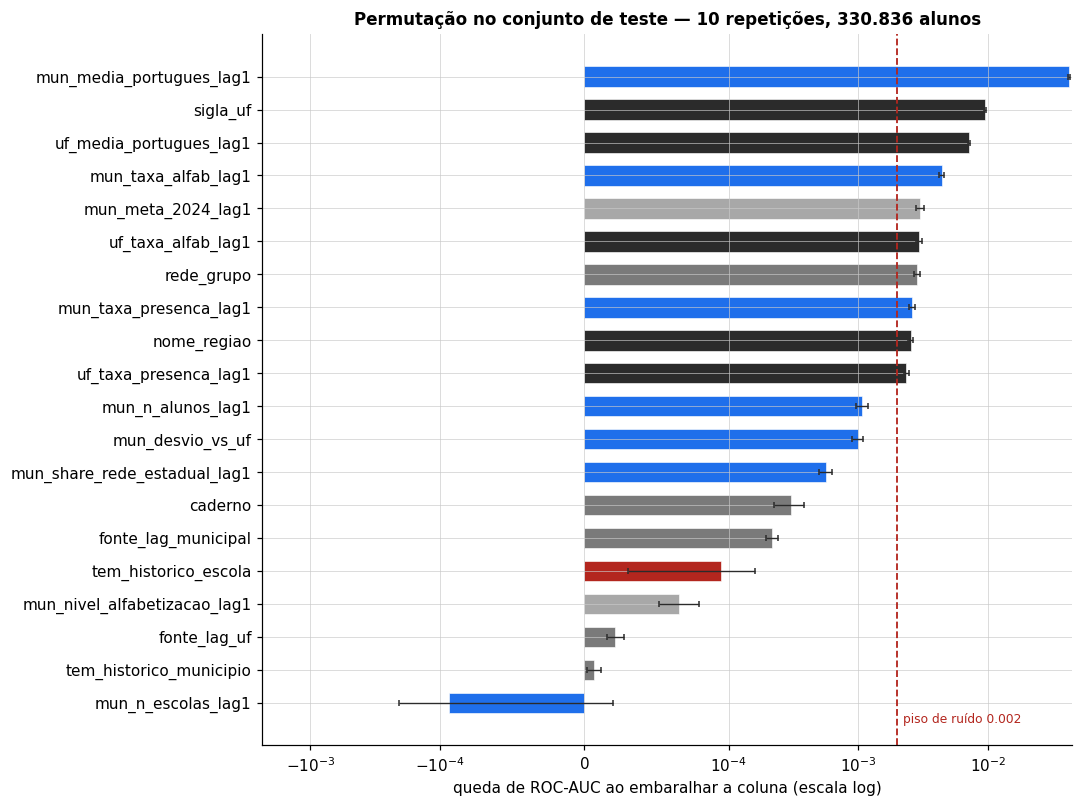

In [8]:
print(permutacao[["feature", "familia", "queda_media", "queda_dp", "acima_do_piso"]]
      .head(12).round(5).to_string(index=False))
print()
print("features acima do piso de ruído:", int(permutacao["acima_do_piso"].sum()), "de", len(permutacao))
print("queda negativa (embaralhar melhora):",
      permutacao.loc[permutacao["queda_media"] < 0, "feature"].tolist())

fig = plots.plotar_permutacao(permutacao)
print(plots.salvar_figura(fig, "04_permutacao_no_teste"))

**Achado 8, dez das vinte features passam do piso de ruído.** As outras dez — incluindo `mun_desvio_vs_uf`, `mun_n_alunos_lag1`, as três colunas de proveniência do lag e o próprio `caderno` — não distinguem importância de acaso quando removidas isoladamente. Elas seguem no modelo porque não atrapalham, não porque façam falta.

**Achado 9, `mun_n_escolas_lag1` tem queda negativa.** Embaralhar o número de escolas do município em 2023 **melhora** a AUC em 0,00009, com desvio de 0,00011. O efeito é indistinguível de zero, mas o sinal importa: a variável é 11ª no SHAP e última na permutação. O modelo a usa, e o que ela acrescenta não sobrevive a ser retirada — leitura clássica de coluna redundante com `mun_n_alunos_lag1`.

**Achado 10, e o mais desconfortável: a ordem muda entre as duas leituras.** `sigla_uf` é 6ª no SHAP e **2ª** na permutação; `mun_meta_2024_lag1` é 10ª no SHAP e 5ª na permutação. A explicação é a mesma nos dois casos — o SHAP fatia a variável entre suas colunas e a permutação a destrói inteira. É por isso que nenhuma das duas leituras decide sozinha.

---
## 6. Coeficientes da logística podada

**Pergunta:** em que direção, e com que magnitude, cada variável entra num modelo que se lê a olho nu?
**Decisão:** a terceira ponta da triangulação, e o formato em que a resposta chega a quem não lê SHAP.

O campeão não tem coeficiente. A leitura vem do modelo linear que ficou 0,0098 de AUC atrás dele com oito colunas e todo VIF abaixo de 3. Cada coeficiente é reajustado nos cinco folds agrupados por município, e o desvio entre eles vai ao lado: coeficiente que troca de sinal entre folds não sustenta afirmação de direção.

                      coluna             familia  coeficiente  razao_de_chances  coeficiente_dp_entre_folds  troca_de_sinal_entre_folds  contribuicao_dp
         mun_taxa_alfab_lag1 historico_municipal      -0.4273            0.6523                      0.0078                       False           0.4273
          uf_taxa_alfab_lag1         territorial      -0.1659            0.8471                      0.0102                       False           0.1659
         nome_regiao_Sudeste         territorial      -0.3097            0.7337                      0.0109                       False           0.1509
      mun_taxa_presenca_lag1 historico_municipal      -0.1174            0.8892                      0.0085                       False           0.1174
         rede_grupo_Estadual          estrutural      -0.3160            0.7291                      0.0255                       False           0.1108
             nome_regiao_Sul         territorial       0.2774            1.3198   

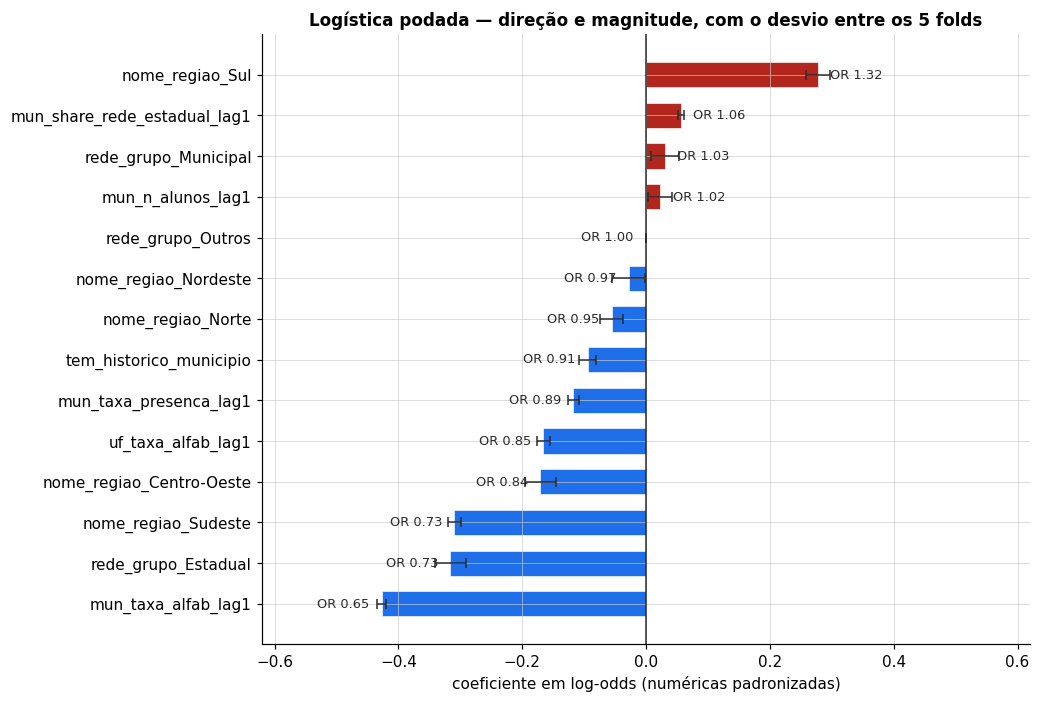

In [9]:
coeficientes = pd.read_csv(it.CSV_COEFICIENTES)
print(coeficientes[["coluna", "familia", "coeficiente", "razao_de_chances",
                    "coeficiente_dp_entre_folds", "troca_de_sinal_entre_folds", "contribuicao_dp"]]
      .round(4).to_string(index=False))

fig = plots.plotar_coeficientes(coeficientes)
print(plots.salvar_figura(fig, "05_coeficientes_logistica"))

**Achado 11, a direção é inequívoca e estável.** `mun_taxa_alfab_lag1` tem coeficiente −0,427 e razão de chances **0,65**: um desvio-padrão a mais na taxa de alfabetização do município em 2023 reduz em 35% a chance de a criança não se alfabetizar em 2024. O desvio entre folds é 0,008, ou seja, 1,8% da magnitude. Nenhuma coluna com contribuição relevante troca de sinal entre folds.

**Achado 12, a rede estadual aparece como fator protetor.** `rede_grupo_Estadual` tem OR **0,73** e a leitura SHAP concorda: matrícula na rede estadual empurra a contribuição para −0,20 em log-odds, contra +0,05 na municipal. A ressalva é obrigatória e vai junto de qualquer uso disso: redes estaduais estão concentradas em municípios de perfil diferente, e o modelo não separa o efeito da rede do efeito de onde ela está. É associação, não efeito de política.

**Achado 13, o Sul aparece com sinal positivo, e isso surpreendeu.** `nome_regiao_Sul` tem OR **1,32**: dada a taxa de alfabetização do município e a da UF em 2023, estar no Sul sobra como risco residual, o oposto do que a taxa bruta da região sugere. A hipótese mais provável está numa medição que a Etapa 4 já tinha registrado por outro caminho, a de que Santa Catarina tem 70,1% de presença na prova contra 98,1% do Ceará. Onde menos crianças comparecem, a taxa municipal de 2023 é otimista, e o modelo linear compensa isso com um deslocamento regional. Não é achado sobre a qualidade do ensino no Sul; é achado sobre a comparabilidade das taxas entre territórios de cobertura muito diferente, e o fato de `mun_taxa_presenca_lag1` entrar ao lado com OR 0,89, na direção esperada, reforça a leitura.

---
## 7. A forma da relação nas quatro variáveis principais

**Pergunta:** o efeito é linear, satura, ou muda de regime?
**Decisão:** se a leitura executiva pode ser dita como "quanto mais X, menos risco" ou precisa de faixa.

O eixo x é o valor **cru** da variável e o eixo y soma os valores SHAP de todas as colunas que ela gera, incluindo o indicador de nulo. A dispersão vertical em cada x é interação com o resto do modelo — se a nuvem fosse uma linha, um modelo aditivo bastaria.

as quatro principais por |SHAP|: ['mun_media_portugues_lag1', 'uf_media_portugues_lag1', 'mun_taxa_alfab_lag1', 'rede_grupo']


images/interpretabilidade/06_dependencia.png


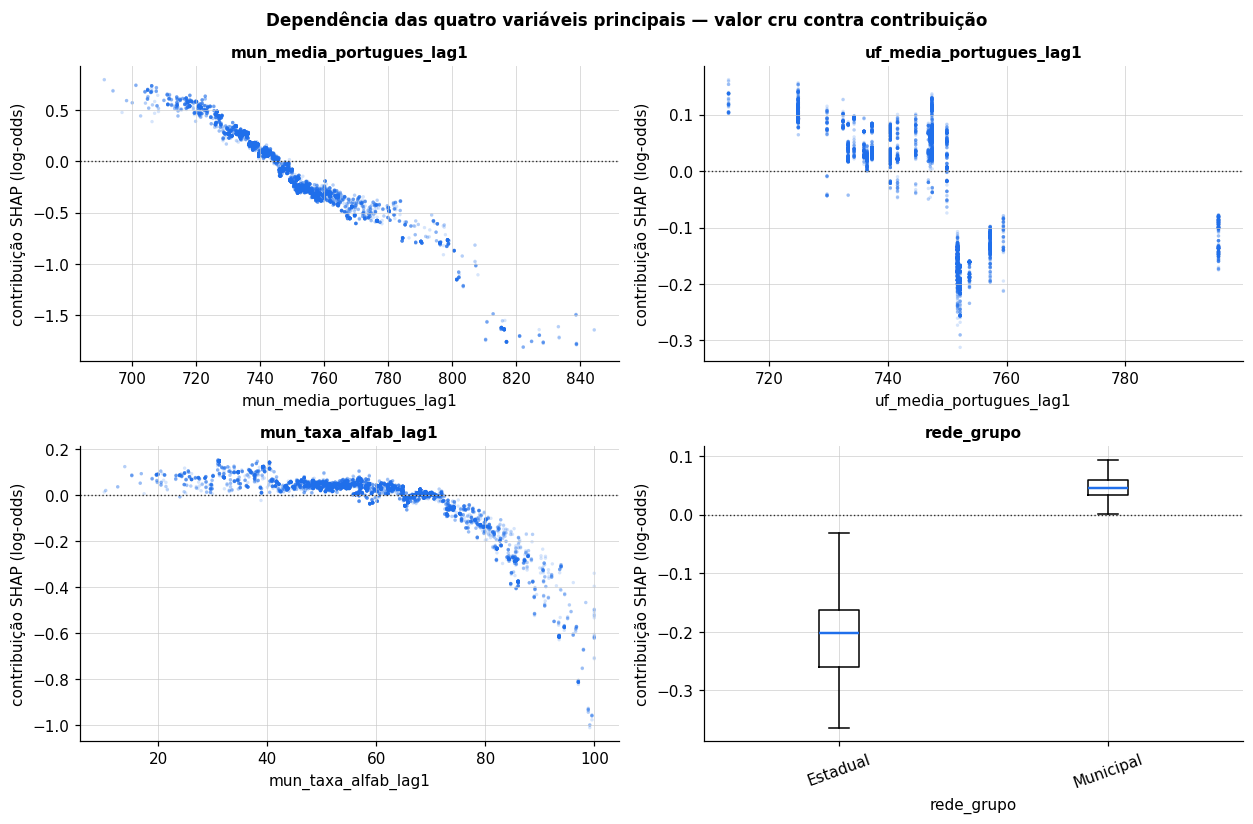

In [10]:
principais = global_.nlargest(4, "media_do_abs_da_soma")["feature"].tolist()
print("as quatro principais por |SHAP|:", principais)

fig = plots.plotar_dependencia(amostra, mapa, principais)
print(plots.salvar_figura(fig, "06_dependencia"))

**Dependência SHAP:** a contribuição de uma variável varia pouco abaixo de 65%. Isso não mede a ordenação do modelo completo, que também usa média de português e outras variáveis. A incerteza das posições permanece não quantificada.

---
## 8. Triangulação — o que é fator e o que é achado sobre a leitura

**Pergunta:** quais variáveis aparecem no topo das três leituras ao mesmo tempo?
**Decisão:** o que pode ser dito como fator na apresentação executiva.

O critério é conservador de propósito: `fator` exige estar no topo de todas as leituras que **conseguem** ver aquela feature, e ainda derrubar mais que o piso de ruído do controle negativo. A logística só enxerga oito das vinte, então para as outras doze a triangulação é de duas pontas — e a tabela declara isso em `leituras_disponiveis`, porque reportar consenso de três quando houve duas seria inflar a confiança do resultado.

                 feature             familia  posicao_shap  posicao_permutacao  posicao_logistica  leituras_disponiveis  leituras_no_topo  acima_do_piso               veredito
mun_media_portugues_lag1 historico_municipal           1.0                 1.0                NaN                     2                 2           True                  fator
                sigla_uf         territorial           6.0                 2.0                NaN                     2                 1           True achado sobre a leitura
 uf_media_portugues_lag1         territorial           2.0                 3.0                NaN                     2                 2           True                  fator
     mun_taxa_alfab_lag1 historico_municipal           3.0                 4.0                1.0                     3                 3           True                  fator
      mun_meta_2024_lag1               metas          10.0                 5.0                NaN                     2 

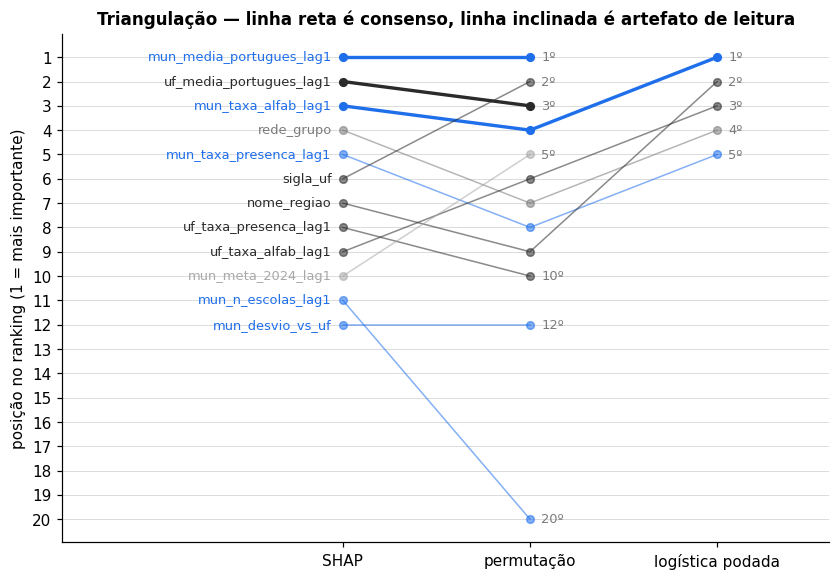

In [11]:
triangulacao = pd.read_csv(it.CSV_TRIANGULACAO)
tri_global = triangulacao[triangulacao["recorte"] == "global"]
print(tri_global[["feature", "familia", "posicao_shap", "posicao_permutacao", "posicao_logistica",
                  "leituras_disponiveis", "leituras_no_topo", "acima_do_piso", "veredito"]]
      .head(12).to_string(index=False))
print()
print(tri_global["veredito"].value_counts().to_string())

fig = plots.plotar_triangulacao(tri_global)
print(plots.salvar_figura(fig, "07_triangulacao"))

**Achado 17, três features passam no critério, e só uma passa nas três leituras.** `mun_media_portugues_lag1` e `uf_media_portugues_lag1` são fatores com duas leituras — não estão no subconjunto podado, então a logística não as vê. `mun_taxa_alfab_lag1` é a única que está no topo do SHAP, no topo da permutação **e** em primeiro lugar na logística. É a variável que sustenta a resposta à pergunta 1 do enunciado sem nenhuma ressalva de método.

**Achado 18, `sigla_uf` é o caso-modelo de achado sobre a leitura.** Segunda colocada na permutação, sexta no SHAP, ausente da logística por decisão da Etapa 3. Ela não entra na lista de fatores, e a razão é metodológica: as 26 dummies diluem o SHAP e a permutação as destrói de uma vez, então as duas técnicas estão medindo objetos diferentes. Reportá-la como fator descreveria a mecânica do `OneHotEncoder`, não a alfabetização.

**Achado 19, seis features ficam em "achado sobre a leitura".** Além de `sigla_uf`, aparecem ali `rede_grupo`, `nome_regiao`, `mun_meta_2024_lag1`, `uf_taxa_alfab_lag1` e `mun_taxa_presenca_lag1`: estão no topo de uma leitura e não das outras. Todas passam do piso de ruído, então nenhuma é descartável — mas nenhuma sustenta sozinha uma frase de recomendação.

---
## 9. A leitura restrita a quem tem histórico de qualidade

**Pergunta:** o ranking global é média de populações que o modelo entende de formas diferentes?
**Decisão:** publicar a leitura global ou substituí-la pela restrita.

A Etapa 4 mediu ROC-AUC 0,6706 onde o lag vem da Gold contra 0,5598 no agregado `rede 3`, e deixou o alerta: uma leitura única mistura três populações. A verificação é direta — refazer a agregação dentro de `fonte_lag_municipal = gold` e comparar.

In [12]:
from scipy.stats import spearmanr

comparado = shap_features.pivot(index="feature", columns="recorte", values="media_do_abs_da_soma")
comparado["variacao"] = comparado["gold"] / comparado["global"] - 1
print(comparado.sort_values("global", ascending=False).head(10).round(4).to_string())
print()
print("Spearman entre as duas ordenações: %.4f" % spearmanr(comparado["global"], comparado["gold"]).statistic)
print()
print(familias.pivot(index="familia", columns="recorte", values="participacao").round(4).to_string())

recorte                   global    gold  variacao
feature                                           
mun_media_portugues_lag1  0.2709  0.2776    0.0246
uf_media_portugues_lag1   0.0827  0.0890    0.0762
mun_taxa_alfab_lag1       0.0653  0.0690    0.0561
rede_grupo                0.0574  0.0526   -0.0835
mun_taxa_presenca_lag1    0.0557  0.0630    0.1320
sigla_uf                  0.0494  0.0554    0.1218
nome_regiao               0.0379  0.0385    0.0156
uf_taxa_presenca_lag1     0.0330  0.0351    0.0641
uf_taxa_alfab_lag1        0.0299  0.0326    0.0894
mun_meta_2024_lag1        0.0290  0.0293    0.0105

Spearman entre as duas ordenações: 0.9940

recorte              global    gold
familia                            
estrutural           0.0907  0.0788
historico_escolar    0.0135  0.0095
historico_municipal  0.5716  0.5688
metas                0.0482  0.0464
territorial          0.2759  0.2964


**Achado 20, a leitura global não é artefato da coalescência — e isso era falseável.** A correlação de Spearman entre as duas ordenações de features é **0,994**, a primeira colocada é a mesma e as participações por família mudam pouco: o histórico municipal vai de 57,2% para 56,9% e o territorial de 27,6% para 29,6%. A verificação que a Etapa 4 exigiu foi feita e passou, o que permite publicar o número agregado sem a ressalva que se esperava precisar.

**Achado 21, o que mais se move é a presença.** `mun_taxa_presenca_lag1` ganha 13,2% de importância na fatia Gold e passa da quinta para a quarta posição, enquanto a família de histórico escolar encolhe de 1,35% para 0,95%. Faz sentido mecânico: onde o lag veio do microdado, a taxa de presença de 2023 é medida sobre a mesma fonte, e não herdada de um agregado do INEP.

**Hipóteses revisadas:** H1 e H5 descrevem associações no recorte observado. H2 é não verificável: IDs reciclados impedem testar histórico escolar verdadeiro. Os resultados foram explorados na mesma população e não constituem confirmação independente.

In [13]:
for hipotese in resumo["hipoteses"]:
    print(f"{hipotese['hipotese']} — {hipotese['veredito'].upper()}")
    print(f"   enunciado : {hipotese['enunciado']}")
    print(f"   falseável : {hipotese['criterio_de_falseamento']}")
    for chave, valor in hipotese["medido"].items():
        print(f"   {chave:38s}: {valor}")
    print()

H1 — SUSTENTADA
   enunciado : o contexto municipal de 2023 é o preditor dominante do risco individual em 2024
   falseável : uma família não municipal aparecer no topo do SHAP
   familia_no_topo_do_shap               : historico_municipal
   familia_no_topo_da_permutacao_em_bloco: historico_municipal
   ordem_shap                            : ['historico_municipal', 'territorial', 'estrutural', 'metas', 'historico_escolar']
   ordem_permutacao                      : ['historico_municipal', 'territorial', 'estrutural', 'metas', 'historico_escolar']

H2 — NÃO VERIFICÁVEL
   enunciado : o histórico escolar verdadeiro acrescentaria sinal além do município?
   falseável : a família de histórico escolar não aparecer no fim da lista
   posicao_no_shap                       : 5
   posicao_na_permutacao                 : 5
   de_um_total_de                        : 5
   ressalva                              : a família se resume a `tem_historico_escola`; o bloco `esc_*` é ligado por identifica

**Hipóteses revisadas:** H1 e H5 descrevem associações no recorte observado. H2 é não verificável: IDs reciclados impedem testar histórico escolar verdadeiro. Os resultados foram explorados na mesma população e não constituem confirmação independente.

---
## Síntese, e o que não se pode concluir daqui

**A resposta à pergunta 1 do enunciado, em uma frase:** o que mais impacta o risco de não alfabetização, neste modelo, é o desempenho do próprio município no ano anterior — proficiência média em português acima de tudo, taxa de alfabetização em seguida —, com o estado em que o município está respondendo por outro quarto da explicação.

**A resposta à pergunta 5, por grupo de variável:** histórico municipal 57,2%, território acima do município 27,6%, estrutural 9,1%, metas 4,8%, histórico escolar 1,3%.

**Três limites que acompanham obrigatoriamente esses números.**

Importância não é causalidade. O SHAP diz o que o modelo usou para prever, não o que aconteceria se alguém interviesse na variável. Elevar a média de português de um município não é uma intervenção — é o resultado que se quer, escrito de outra forma. A pergunta causal exige desenho causal, e esta base não o oferece.

Toda feature aqui é contextual, e aplicá-la a uma criança é falácia ecológica. O modelo descreve o território em que a criança está, não a criança. É o mesmo achado que a Etapa 4 mediu por outro caminho: embaralhando o alvo dentro de cada município, a AUC cai de 0,6667 para 0,6636.

O ranking descreve 2024. O teste de drift da Etapa 4 mostrou que a estrutura territorial se desloca entre edições — o modelo reduzido a UF, região e rede cai de 0,6306 dentro de 2024 para 0,6099 quando treinado em 2023. A ordem de importância medida aqui vale para esta coorte, e projetar 2026 a partir dela assumiria uma estabilidade que a medição desmente.